In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [10]:
df = pd.read_csv('train.csv')

df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [11]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

df.info()

Shape: (421570, 5)

Columns:
Index(['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
dtypes: bool(1), float64(1), int64(2), object(1)
memory usage: 13.3+ MB


In [12]:
df.isnull().sum()

,0
Store,0
Dept,0
Date,0
Weekly_Sales,0
IsHoliday,0


In [13]:
df.describe()

,Store,Dept,Weekly_Sales
count,421570.000000,421570.000000,421570.000000
mean,22.200546,44.260317,15981.258123
std,12.785297,30.492054,22711.183519
min,1.000000,1.000000,-4988.940000
25%,11.000000,18.000000,2079.650000
50%,22.000000,37.000000,7612.030000
75%,33.000000,74.000000,20205.852500
max,45.000000,99.000000,693099.360000


In [14]:
df['Date'] = pd.to_datetime(df['Date'])

print("Start Date:", df['Date'].min())
print("End Date:", df['Date'].max())

Start Date: 2010-02-05 00:00:00
End Date: 2012-10-26 00:00:00


In [15]:
print("Number of Stores:", df['Store'].nunique())
print("Number of Departments:", df['Dept'].nunique())

Number of Stores: 45
Number of Departments: 81


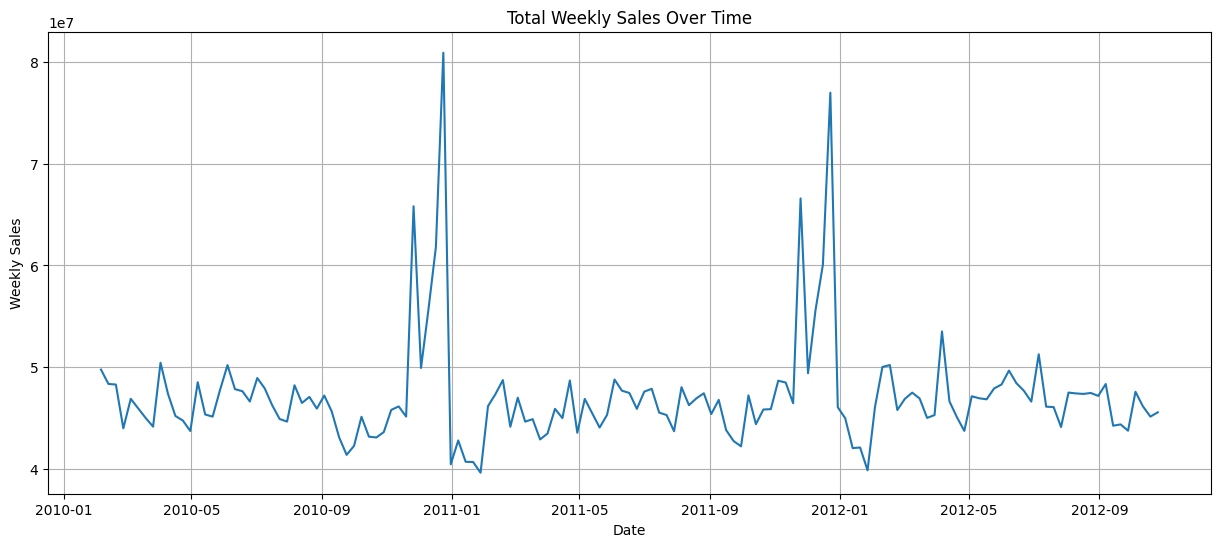

In [16]:
# Total sales over time

sales_trend = df.groupby('Date')['Weekly_Sales'].sum().reset_index()

plt.figure(figsize=(15,6))
plt.plot(sales_trend['Date'], sales_trend['Weekly_Sales'])
plt.title('Total Weekly Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.grid(True)
plt.show()

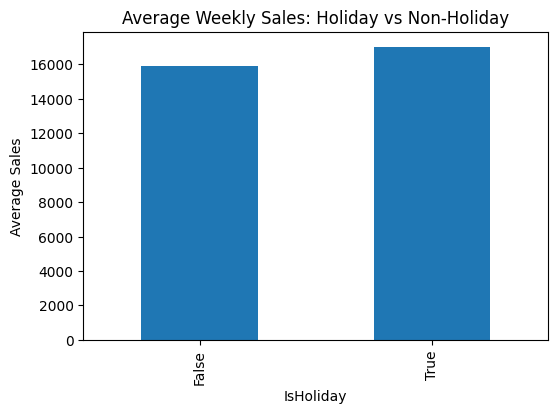

In [17]:
holiday_sales = df.groupby('IsHoliday')['Weekly_Sales'].mean()

plt.figure(figsize=(6,4))
holiday_sales.plot(kind='bar')
plt.title('Average Weekly Sales: Holiday vs Non-Holiday')
plt.ylabel('Average Sales')
plt.show()

In [18]:
print(df.shape)

(421570, 5)


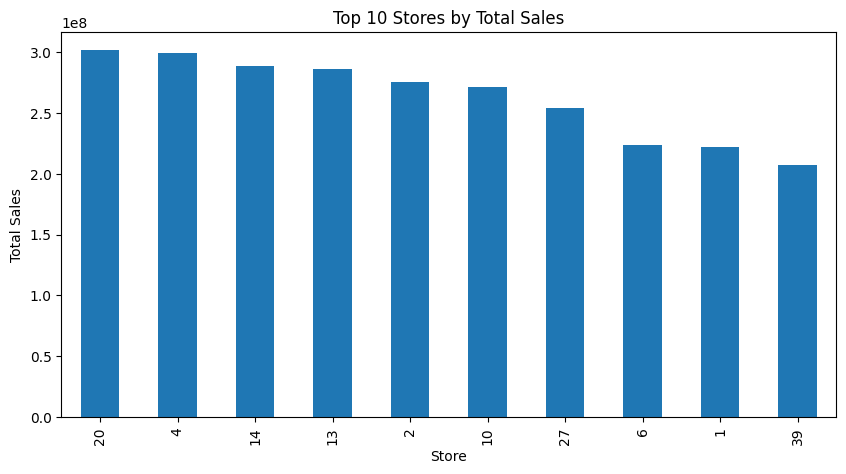

In [19]:
top_stores = df.groupby('Store')['Weekly_Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_stores.plot(kind='bar')

plt.title('Top 10 Stores by Total Sales')
plt.ylabel('Total Sales')

plt.show()

In [20]:
# Feature Engineering

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Week'] = df['Date'].dt.isocalendar().week

df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Year,Month,Week
0,1,1,2010-02-05,24924.50,False,2010,2,5
1,1,1,2010-02-12,46039.49,True,2010,2,6
2,1,1,2010-02-19,41595.55,False,2010,2,7
3,1,1,2010-02-26,19403.54,False,2010,2,8
4,1,1,2010-03-05,21827.90,False,2010,3,9


In [21]:
features = ['Store', 'Dept', 'IsHoliday', 'Year', 'Month', 'Week']

X = df[features]
y = df['Weekly_Sales']

print(X.shape)
print(y.shape)

(421570, 6)
(421570,)


In [22]:
X['IsHoliday'] = X['IsHoliday'].astype(int)

X.head()

/tmp/ipykernel_2232/744097900.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['IsHoliday'] = X['IsHoliday'].astype(int)


,Store,Dept,IsHoliday,Year,Month,Week
0,1,1,0,2010,2,5
1,1,1,1,2010,2,6
2,1,1,0,2010,2,7
3,1,1,0,2010,2,8
4,1,1,0,2010,3,9


In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(337256, 6)
(84314, 6)


In [24]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

print("Model Training Complete!")

Model Training Complete!


In [25]:
predictions = model.predict(X_test)

print(predictions[:10])

[50261.8227  3101.3612 10620.8252  3960.4526  5404.972   8469.0748
  1625.4644 19979.0921  6310.9424 15004.5185]


In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 1432.1055759944963
RMSE: 4010.7870110627487
R² Score: 0.9691518556778468


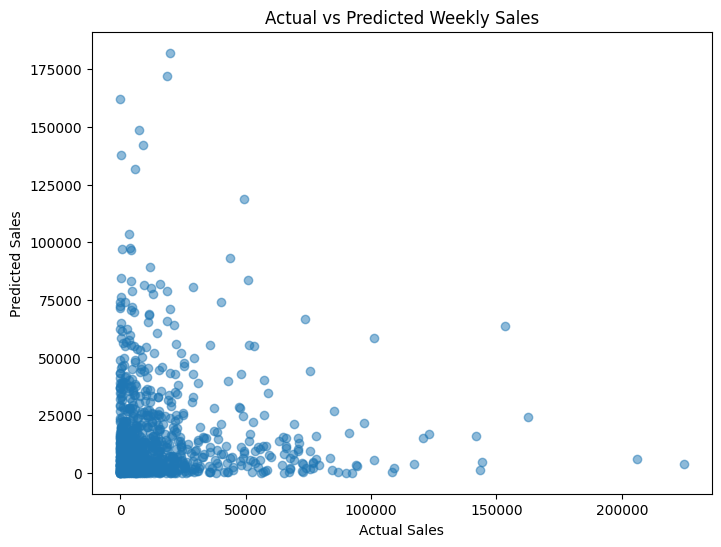

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    y_test.sample(1000, random_state=42),
    predictions[:1000],
    alpha=0.5
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Weekly Sales")

plt.show()

In [28]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

     Feature  Importance
1       Dept    0.558618
0      Store    0.370350
5       Week    0.052413
4      Month    0.008554
3       Year    0.007787
2  IsHoliday    0.002277


In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 1432.1055759944963
RMSE: 4010.7870110627487
R² Score: 0.9691518556778468
